# HW3 Image Classification
## We strongly recommend that you run with [Kaggle](https://www.kaggle.com/t/86ca241732c04da99aca6490080bae73) for this homework

If you have any questions, please contact the TAs via TA hours, NTU COOL, or email to mlta-2023-spring@googlegroups.com

# Check GPU Type

In [5]:
!nvidia-smi

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Thu Jul  2 12:25:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             13W /   70W |       0MiB /  15360MiB |      0%  

In [11]:
torch.cuda.is_available()

True

# Get Data
Notes: if the links are dead, you can download the data directly from Kaggle and upload it to the workspace, or you can use the Kaggle API to directly download the data into colab.


In [26]:
# Download Link
# Link 1 (Dropbox): https://www.dropbox.com/s/up5q1gthsz3v0dq/food-11.zip?dl=0
# Link 2 (Google Drive): https://drive.google.com/file/d/1tbGNwk1yGoCBdu4Gi_Cia7EJ9OhubYD9/view?usp=share_link
# Link 3: Kaggle Competition.

# (1) dropbox link
# !wget -O food11.zip https://www.dropbox.com/s/up5q1gthsz3v0dq/food-11.zip?dl=0

# (2) google drive link
#!pip install gdown --upgrade
#!gdown --id '1tbGNwk1yGoCBdu4Gi_Cia7EJ9OhubYD9' --output food11.zip

import os

# Kaggle competition 資料集會自動掛載在 /kaggle/input/
# 確認資料夾內容
os.listdir('/kaggle/input/competitions/ml2023spring-hw3')

['valid', 'test', 'train']

In [28]:
_exp_name = "sample"

In [29]:
# Import necessary packages.
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
# ConcatDataset / Subset 在做 semi-supervised 時有用
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
from tqdm.auto import tqdm
import random

In [30]:
myseed = 6666  # 固定隨機種子，確保實驗可重現
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# Transforms
TorchVision 提供豐富的影像前處理、包裝與資料增強工具。

**重要觀念：**
- `test_tfm`（驗證 / 測試用）：只做最基本的 Resize + Normalize，確保評估結果的一致性
- `train_tfm`（訓練用）：加入隨機增強，讓模型學到更好的泛化能力（Q1 要求）
    
test_tfm:   Resize → ToTensor → Normalize

train_tfm:  Resize → [6種隨機增強] → ToTensor → Normalize

PIL Image (HWC, int 0~255)

    ↓  ToTensor()

tensor (CHW, float 0.0~1.0)

    ↓  Normalize()

tensor (CHW, float 約 -2~+2)

    ↓  丟進模型

**增強模擬的真實情境**

RandomHorizontalFlip  手機拿反了拍

RandomVerticalFlip    相機倒過來拍

RandomRotation        照片角度歪斜

ColorJitter           光線不同、濾鏡效果

RandomCrop            食物不在畫面正中間

RandomGrayscale       灰階，讓模型靠形狀而非顏色來判斷

In [32]:
# ImageNet 的 mean / std，用於 Normalize
# 若你的資料集非 ImageNet，理想上應算自己資料集的統計量
# 但實務上用 ImageNet 的值已有不錯效果
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── 測試 / 驗證用 transform（不做隨機增強，保持結果一致）──
test_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    # Normalize 將每個 channel 調整到以 0 為中心的分佈
    # 可加速收斂並穩定訓練
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 訓練用 transform（Q1 實作：需能對同一張圖產生 5+ 種不同結果）──
train_tfm = transforms.Compose([
    transforms.Resize((128, 128)),

    # [增強 1] 隨機水平翻轉，p=0.5 → 每張圖有 50% 機率被翻轉
    transforms.RandomHorizontalFlip(p=0.5),

    # [增強 2] 隨機垂直翻轉（食物圖片較少用，但仍可增加多樣性）
    transforms.RandomVerticalFlip(p=0.2),

    # [增強 3] 隨機旋轉 ±30 度
    transforms.RandomRotation(degrees=30),

    # [增強 4] 顏色抖動：隨機改變亮度、對比、飽和度、色相
    # 讓模型不依賴固定的顏色特徵來分類
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),

    # [增強 5] 隨機裁切：先 padding 再裁回原尺寸
    # 模擬照片構圖不同的情境
    transforms.RandomCrop(128, padding=16),

    # [增強 6] 隨機灰階（以 p=0.1 機率將圖片轉為灰階）
    # 讓模型學到形狀而非純粹顏色資訊
    transforms.RandomGrayscale(p=0.1),

    # ToTensor 必須在 Normalize 之前，且應為最後幾步之一
    transforms.ToTensor(),

    # Normalize（與 test_tfm 一致）
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Datasets
資料標籤直接編碼在檔名中（例如 `0_xxxx.jpg` → label = 0），
`__getitem__` 在讀取時動態解析標籤。

In [34]:
class FoodDataset(Dataset):

    def __init__(self, path, tfm=test_tfm, files=None):
        super(FoodDataset).__init__()
        self.path = path
        # 取出資料夾內所有 .jpg 檔案，排序後確保每次順序一致
        self.files = sorted([
            os.path.join(path, x)
            for x in os.listdir(path)
            if x.endswith(".jpg")
        ])
        if files is not None:
            self.files = files
        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        im = Image.open(fname)
        im = self.transform(im)

        # 檔名格式：{label}_{id}.jpg
        # os.path.basename 相容 Windows / Linux 路徑分隔符號
        try:
            label = int(os.path.basename(fname).split("_")[0])
        except:
            label = -1  # test set 沒有 label
        return im, label

# Model

CNN 架構說明：
- 5 個 Conv Block，每個 block = Conv2d → BatchNorm → ReLU → MaxPool
- 每個 block 將 feature map 的空間尺寸減半（MaxPool stride=2）
- 最終輸出 feature map 大小：512 × 4 × 4
- FC 層：8192 → 1024 → 512 → 11（11 個食物類別）

**新增 Dropout** 在 FC 層防止過擬合

In [35]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        # ── CNN Feature Extractor ──
        # 輸入維度 [B, 3, 128, 128]
        self.cnn = nn.Sequential(
            # Block 1: [B, 3, 128, 128] → [B, 64, 64, 64]
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),   # 批次正規化，穩定訓練
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: [B, 64, 64, 64] → [B, 128, 32, 32]
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: [B, 128, 32, 32] → [B, 256, 16, 16]
            # （此處即 "mid layer"，適合做 t-SNE 視覺化）
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4: [B, 256, 16, 16] → [B, 512, 8, 8]
            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 5: [B, 512, 8, 8] → [B, 512, 4, 4]
            # （此處為 "top layer"，最接近輸出的高階特徵）
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # ── Fully Connected Classifier ──
        self.fc = nn.Sequential(
            nn.Linear(512 * 4 * 4, 1024),
            nn.ReLU(),
            # Dropout：訓練時隨機關閉 30% 神經元，迫使模型學更穩健的特徵
            # eval() 時 Dropout 自動關閉
            nn.Dropout(p=0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),   # 防止 over fitting
            nn.Linear(512, 11),  # 11 個食物類別
        )

    def forward(self, x):
        out = self.cnn(x)
        out = out.view(out.size(0), -1)  # Flatten: [B, 512*4*4]
        return self.fc(out)

# Configurations

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用裝置：{device}")

model = Classifier().to(device)

batch_size = 64

# 原本只有 8 個 epoch 對 Food-11 來說太少
# 已設定 early stopping，不用擔心跑太多 epoch 浪費時間
n_epochs = 50

# 連續 patience 個 epoch validation accuracy 沒進步就提前停止
patience = 10

criterion = nn.CrossEntropyLoss()

# Adam optimizer：讓 learning rate 隨訓練進度自動降低
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

# ── 新增：學習率排程器（Cosine Annealing）──
# 讓學習率從初始值逐漸降低到 0，有助於在訓練後期精細調整參數
# T_max = n_epochs 代表完整跑一個 cosine 週期
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=n_epochs, eta_min=1e-6
)

使用裝置：cuda


# Dataloader

In [37]:
#train_set = FoodDataset("./train", tfm=train_tfm)
#valid_set = FoodDataset("./valid", tfm=test_tfm)
DATA_DIR  = "/kaggle/input/competitions/ml2023spring-hw3"
train_set = FoodDataset(f"{DATA_DIR}/train", tfm=train_tfm)
valid_set = FoodDataset(f"{DATA_DIR}/valid", tfm=test_tfm)
test_set  = FoodDataset(f"{DATA_DIR}/test",  tfm=test_tfm)

# num_workers：背景預載資料的 process 數
# Kaggle / Colab 上建議設 2，Windows 本機若有問題可改回 0
train_loader = DataLoader(
    train_set, batch_size=batch_size,
    shuffle=True, num_workers=2, pin_memory=True
)
valid_loader = DataLoader(
    valid_set, batch_size=batch_size,
    shuffle=False,  # 驗證集不需要 shuffle
    num_workers=2, pin_memory=True
)
print(f"訓練集大小：{len(train_set)}　驗證集大小：{len(valid_set)}")

訓練集大小：10000　驗證集大小：3643


# Start Training

In [38]:
stale = 0
best_acc = 0

for epoch in range(n_epochs):

    # ────────── Training ──────────
    model.train()  # 切換到訓練模式（啟用 Dropout、BatchNorm 的訓練行為）
    train_loss = []
    train_accs = []

    for batch in tqdm(train_loader):
        imgs, labels = batch
        logits = model(imgs.to(device))

        # CrossEntropyLoss 內部已包含 Softmax，不需要額外加
        loss = criterion(logits, labels.to(device))

        optimizer.zero_grad()   # 清除上一步的梯度
        loss.backward()         # 反向傳播，計算梯度

        # Gradient Clipping：避免梯度爆炸，max_norm=10 是常見設定
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)

        optimizer.step()        # 更新參數

        acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()
        train_loss.append(loss.item())
        train_accs.append(acc)

    train_loss = sum(train_loss) / len(train_loss)
    train_acc  = sum(train_accs) / len(train_accs)
    print(f"[ Train | {epoch+1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")

    # ────────── Validation ──────────
    model.eval()  # 切換到評估模式（關閉 Dropout，BatchNorm 使用 running stats）
    valid_loss = []
    valid_accs = []

    for batch in tqdm(valid_loader):
        imgs, labels = batch
        with torch.no_grad():   # 驗證不需要梯度，節省記憶體與運算
            logits = model(imgs.to(device))
        loss = criterion(logits, labels.to(device))
        acc  = (logits.argmax(dim=-1) == labels.to(device)).float().mean()
        valid_loss.append(loss.item())
        valid_accs.append(acc)

    valid_loss = sum(valid_loss) / len(valid_loss)
    valid_acc  = sum(valid_accs) / len(valid_accs)
    print(f"[ Valid | {epoch+1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}")

    # ── 更新 log 檔 ──
    log_msg = f"[ Valid | {epoch+1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}"
    if valid_acc > best_acc:
        log_msg += " -> best"
    with open(f"./{_exp_name}_log.txt", "a") as f:  
        print(log_msg, file=f)                        

    # ── 儲存最佳模型 & Early Stopping ──
    if valid_acc > best_acc:
        print(f"Best model found at epoch {epoch+1}, saving model")
        torch.save(model.state_dict(), f"{_exp_name}_best.ckpt")
        best_acc = valid_acc
        stale = 0
    else:
        stale += 1
        if stale > patience:
            print(f"連續 {patience} 個 epoch 無進步，提前停止訓練")
            break

    # ── 每個 epoch 結束後更新學習率（Cosine Annealing）──
    scheduler.step()
    print(f"   目前學習率：{scheduler.get_last_lr()[0]:.2e}")

print(f"\n訓練完成！最佳驗證準確率：{best_acc:.5f}")

# 訓練完成！最佳驗證準確率：0.73165

  0%|          | 0/157 [00:00<?, ?it/s]

[ Train | 001/050 ] loss = 2.19584, acc = 0.21955


  0%|          | 0/57 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e3673d971a0>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e3673d971a0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    Traceback (most recent call last):
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()    
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

      if w.is_alive(): 
           ^^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._par

[ Valid | 001/050 ] loss = 2.02863, acc = 0.26508
Best model found at epoch 1, saving model
   目前學習率：3.00e-04


...

  0%|          | 0/157 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e3673d971a0>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e3673d971a0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
  Exception ignored in:  Exception ignored in:   <function _MultiProcessingDataLoaderIter.__del__ at 0x7e3673d971a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7e3673d971a0>  

^ Traceback (most recent cal

[ Train | 050/050 ] loss = 0.83010, acc = 0.71258


  0%|          | 0/57 [00:00<?, ?it/s]

[ Valid | 050/050 ] loss = 0.81212, acc = 0.72756
   目前學習率：1.00e-06

訓練完成！最佳驗證準確率：0.73165


# Dataloader for test

In [40]:
test_set    = FoodDataset("/kaggle/input/competitions/ml2023spring-hw3/test", tfm=test_tfm)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Testing and generate prediction CSV

In [41]:
model_best = Classifier().to(device)
model_best.load_state_dict(torch.load(f"{_exp_name}_best.ckpt"))
model_best.eval()

prediction = []
with torch.no_grad():
    for data, _ in tqdm(test_loader):
        test_pred  = model_best(data.to(device))
        # argmax 取預測類別（原本用 np.argmax 也可，這裡改用 torch 寫法更簡潔）
        test_label = test_pred.argmax(dim=1).cpu().numpy()
        prediction += test_label.tolist()

  0%|          | 0/47 [00:00<?, ?it/s]

In [42]:
def pad4(i):
    return str(i).zfill(4)  # zfill 比字串乘法更易讀

df = pd.DataFrame()
df["Id"]       = [pad4(i) for i in range(len(test_set))]
df["Category"] = prediction
df.to_csv("submission.csv", index=False)
print("submission.csv 已儲存，預覽：")
print(df.head())

submission.csv 已儲存，預覽：
     Id  Category
0  0000         5
1  0001         1
2  0002         0
3  0003         3
4  0004         9


In [46]:
from IPython.display import FileLink
FileLink('submission.csv')

/kaggle/working/submission.csv

# Q1. Augmentation Implementation
## 實作 Data Augmentation（貼到 GradeScope 的版本）

**要求：** `train_tfm` 對同一張圖至少能產生 5 種以上不同的結果

以下為符合作業要求、可直接提交的版本：

In [43]:
# ── Q1 ──
train_tfm = transforms.Compose([
    transforms.Resize((128, 128)),

    # 增強 1：隨機水平翻轉（左右鏡像）
    transforms.RandomHorizontalFlip(p=0.5),

    # 增強 2：隨機垂直翻轉
    transforms.RandomVerticalFlip(p=0.2),

    # 增強 3：隨機旋轉 ±30 度
    transforms.RandomRotation(degrees=30),

    # 增強 4：顏色抖動（亮度、對比、飽和度、色相）
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),

    # 增強 5：隨機裁切（padding 後再裁回 128x128）
    transforms.RandomCrop(128, padding=16),

    # 增強 6：隨機灰階（10% 機率）
    transforms.RandomGrayscale(p=0.1),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Q2. Visual Representations Implementation
## 用 t-SNE 視覺化 CNN 各層的特徵表示

**要求：**
- 擷取 **mid layer**（中間層）和 **top layer**（最後卷積層）的輸出
- 分別跑 t-SNE 並產出 2 張散點圖

**本模型的 layer index 對應：**
- `model.cnn[:6]`  → Block 1–2 後，即 **mid layer**（低階紋理特徵）
- `model.cnn[:15]` → 全部 5 個 block 後，即 **top layer**（高階語義特徵）

In [44]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.cm as cm
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 載入已訓練好的模型
model = Classifier().to(device)
state_dict = torch.load(f"{_exp_name}_best.ckpt")
model.load_state_dict(state_dict)
model.eval()
print(model)

# 確認 CNN 各 sub-layer 的 index（方便選 mid / top layer）
print("\nCNN sub-layers:")
for i, layer in enumerate(model.cnn):
    print(f"  [{i}] {layer}")

Classifier(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


Extracting [Mid Layer (Block 1-2)]: 100%|██████████| 57/57 [00:24<00:00,  2.32it/s]


[Mid Layer (Block 1-2)] feature 維度：(3643, 131072)
[Mid Layer (Block 1-2)] 執行 t-SNE 中（可能需要數分鐘）...


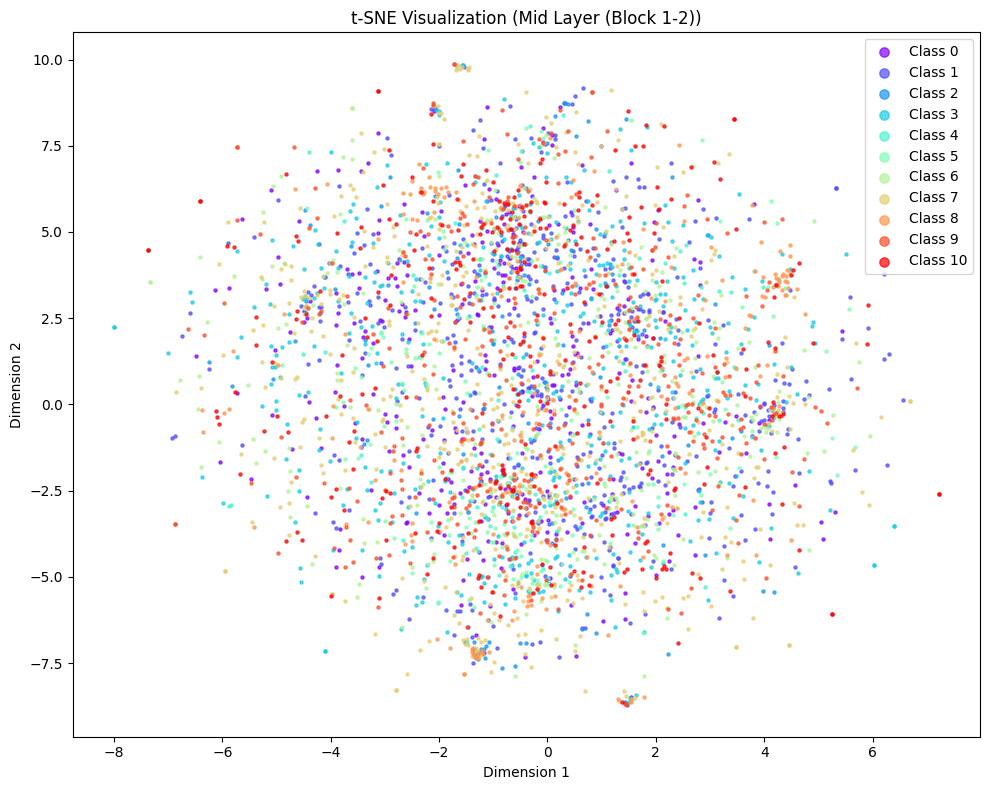

圖片已儲存為 tsne_Mid_Layer_(Block_1-2).png


Extracting [Top Layer (Block 1-5)]: 100%|██████████| 57/57 [00:20<00:00,  2.73it/s]


[Top Layer (Block 1-5)] feature 維度：(3643, 131072)
[Top Layer (Block 1-5)] 執行 t-SNE 中（可能需要數分鐘）...


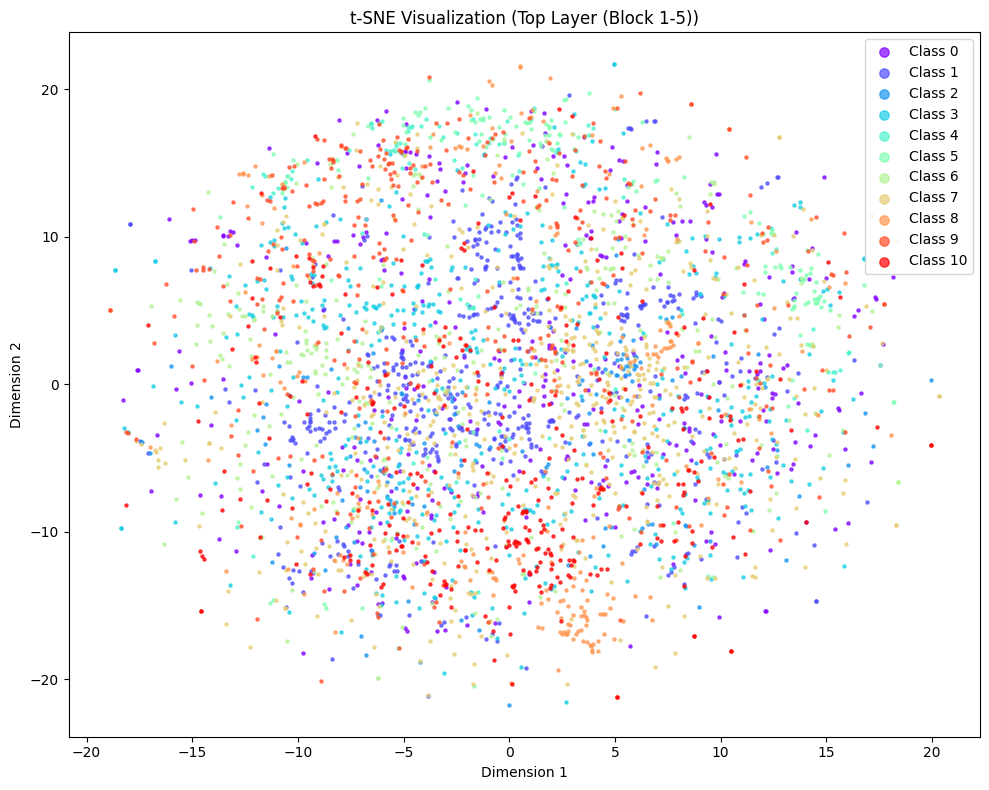

圖片已儲存為 tsne_Top_Layer_(Block_1-5).png


In [45]:
# ── 載入驗證集 ──
valid_set    = FoodDataset("/kaggle/input/competitions/ml2023spring-hw3/valid", tfm=test_tfm)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# ── t-SNE 視覺化函式 ──
def visualize_tsne(model, valid_loader, layer_index, title, device):
    """
    擷取 model.cnn[:layer_index] 的輸出，
    降維到 2D 並畫出各類別的散點圖。

    Args:
        layer_index: 要截斷的 CNN index
                     6  = mid layer（Block 1~2 後）
                     15 = top layer（Block 1~5 全部後）
    """
    features_list = []
    labels_list   = []

    for imgs, lbls in tqdm(valid_loader, desc=f"Extracting [{title}]"):
        with torch.no_grad():
            # 只跑到指定 layer 為止，取得 feature map
            feat = model.cnn[:layer_index](imgs.to(device))
            # Flatten 成 1D vector
            feat = feat.view(feat.size(0), -1)
        features_list.extend(feat.cpu().numpy())
        labels_list.extend(lbls.numpy())

    features = np.array(features_list)  # shape: (N, D)
    labels   = np.array(labels_list)    # shape: (N,)

    print(f"[{title}] feature 維度：{features.shape}")

    # ── 執行 t-SNE 降維（將高維特徵降到 2D）──
    # init='pca' 比 random init 更穩定
    print(f"[{title}] 執行 t-SNE 中（可能需要數分鐘）...")
    features_2d = TSNE(
        n_components=2, init='pca', random_state=42, perplexity=30
    ).fit_transform(features)

    # ── 繪圖 ──
    plt.figure(figsize=(10, 8))
    colors = cm.rainbow(np.linspace(0, 1, 11))
    for label_id in np.unique(labels):
        mask = (labels == label_id)
        plt.scatter(
            features_2d[mask, 0], features_2d[mask, 1],
            label=f"Class {label_id}",
            color=colors[label_id],
            s=5, alpha=0.7
        )
    plt.legend(markerscale=3, loc='best')
    plt.title(f"t-SNE Visualization ({title})")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.tight_layout()
    plt.savefig(f"tsne_{title.replace(' ', '_')}.png", dpi=150)
    plt.show()
    print(f"圖片已儲存為 tsne_{title.replace(' ', '_')}.png")

# ── Mid Layer：Block 1~2 後（index=6，低階特徵如邊緣、紋理）──
# CNN index: [0]=Conv [1]=BN [2]=ReLU [3]=Pool [4]=Conv [5]=BN [6]=ReLU ...
# 截到 index=8 剛好取完 Block 1~2 的 MaxPool
visualize_tsne(model, valid_loader, layer_index=8,  title="Mid Layer (Block 1-2)", device=device)

# ── Top Layer：全部 5 個 Block 後（index=15，高階語義特徵）──
visualize_tsne(model, valid_loader, layer_index=15, title="Top Layer (Block 1-5)", device=device)